In [2]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns

from math import factorial

import matplotlib.pyplot as plt

from scipy import optimize

from kineticanalysis.generator.generator_track import (generate_tracks,
                                                        generate_one_track,
                                                        generate_profile)
from kineticanalysis.analysis.analysis_track import (autocorrelation,
                                                    fit_function,
                                                    single_track_analysis)

In [21]:
%pdb

Automatic pdb calling has been turned ON


In [3]:
def generate_one_track(prot_length,
                       suntag_length,
                       nb_suntag,
                       fluo_one_suntag,
                       translation_rate,
                       binding_rate,
                       retention_time=0,
                       suntag_pos="begin",
                       noise=False,
                       noise_std=0,
                       step=0.1,
                       length=6000,
                       ):
    x, y = generate_profile(prot_length,
                            suntag_length,
                            nb_suntag,
                            fluo_one_suntag,
                            translation_rate,
                            retention_time,
                            suntag_pos,
                            step,
                            noise,
                            noise_std
                            )

    # global signal
    x_global = np.arange(length, step=step)
    y_global = np.zeros(len(x_global))
    y_start_prot = np.zeros(len(x_global))

    n_rand = np.random.rand(len(x_global))
    for i in range(len(x_global)):
        # random number between 0 and 1
        if n_rand[i] < (binding_rate * step):
            if i > (len(x_global) - len(x)):
                y_global[i:i + len(x)] += y[:len(y_global[i:i + len(x)])]
                y_start_prot[i:i + len(x)] += 1
            else:
                y_global[i:i + len(x)] += y
                y_start_prot[i:i + len(x)] += 1

    # Remove the first time points
    # x_global = x_global[2000:] - 200  # -200 to start time at 0
    # y_global = y_global[2000:]
    # y_start_prot = y_start_prot[2000:]

    return x_global, y_global, y_start_prot

def generate_track_no_random(prot_length,
                       suntag_length,
                       nb_suntag,
                       fluo_one_suntag,
                       translation_rate,
                       binding_rate,
                       retention_time=0,
                       suntag_pos="begin",
                       noise=False,
                       noise_std=0,
                       step=0.1,
                       length=6000,):
    
    x, y = generate_profile(prot_length,
                            suntag_length,
                            nb_suntag,
                            fluo_one_suntag,
                            translation_rate,
                            retention_time,
                            suntag_pos,
                            step,
                            noise,
                            noise_std
                            )

    x_global = np.arange(length, step=step)
    y_global = np.zeros(len(x_global))
    y_start_prot = np.zeros(len(x_global))
    sec_rib = 1/binding_rate
    print(sec_rib)
    # binding rate = ribosome / sec
    for i in range(0, len(x_global), int(sec_rib/step)):
        y_global[i:i + len(x)] += y[:len(y_global[i:i + len(x)])]
        y_start_prot[i:i + len(x)] += 1

    # Remove the first time points
    # x_global = x_global[2000:] - 200  # -200 to start time at 0
    # y_global = y_global[2000:]
    # y_start_prot = y_start_prot[2000:]

    return x_global, y_global, y_start_prot


3.0303030303030303


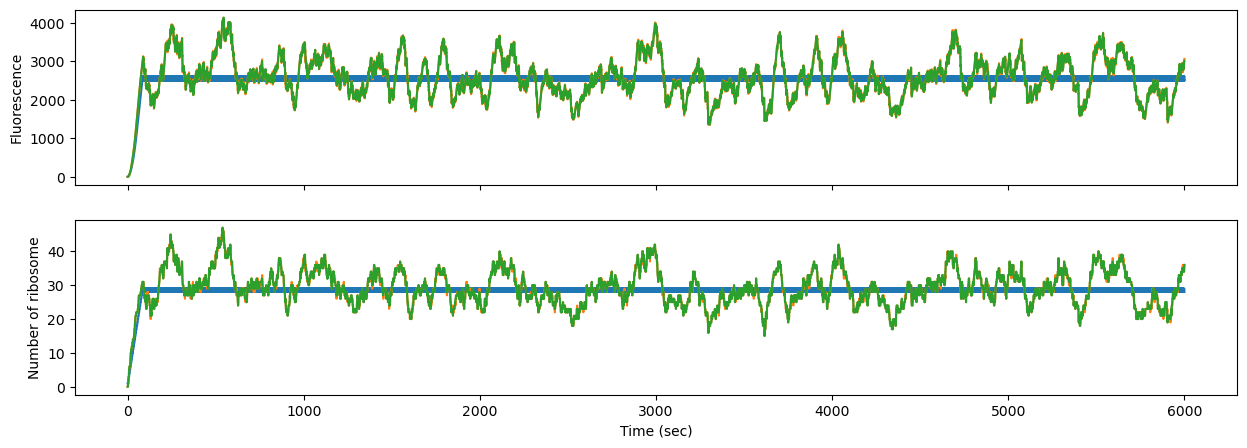

In [86]:
suntag_length = 796
prot_length = 500
nb_suntag = 32
fluo_one_suntag = 4
translation_rate = 15
binding_rate = 0.33
step = 0.1
length = 6000


x_global, y_global, y_start = generate_track_no_random(prot_length=prot_length,
                                                       suntag_length=suntag_length,
                                                       nb_suntag=nb_suntag,
                                                       fluo_one_suntag=fluo_one_suntag,
                                                       translation_rate=translation_rate,
                                                       binding_rate=binding_rate,
                                                       step=step,
                                                       length=length
                                                      )

x_global1, y_global1, y_start1 = generate_one_track(prot_length=prot_length,
                                                       suntag_length=suntag_length,
                                                       nb_suntag=nb_suntag,
                                                       fluo_one_suntag=fluo_one_suntag,
                                                       translation_rate=translation_rate,
                                                       binding_rate=binding_rate,
                                                       step=step,
                                                       length=length)
fig, axes = plt.subplots(nrows = 2, sharex=True)
max_ = 60000 # nb_point
step_ = 1
axes[0].plot(x_global[::step_][:max_], y_global[::step_][:max_])
axes[1].plot(x_global[::step_][:max_], y_start[::step_][:max_])
axes[0].plot(x_global1[::step_][:max_], y_global1[::step_][:max_])
axes[1].plot(x_global1[::step_][:max_], y_start1[::step_][:max_])

max_ = 6000  # nb point
step_ = 10
axes[0].plot(x_global1[::step_][:max_], y_global1[::step_][:max_])
axes[1].plot(x_global1[::step_][:max_], y_start1[::step_][:max_])

axes[0].set_ylabel("Fluorescence")
axes[1].set_ylabel("Number of ribosome")
axes[1].set_xlabel("Time (sec)")

fig.set_size_inches((15,5))

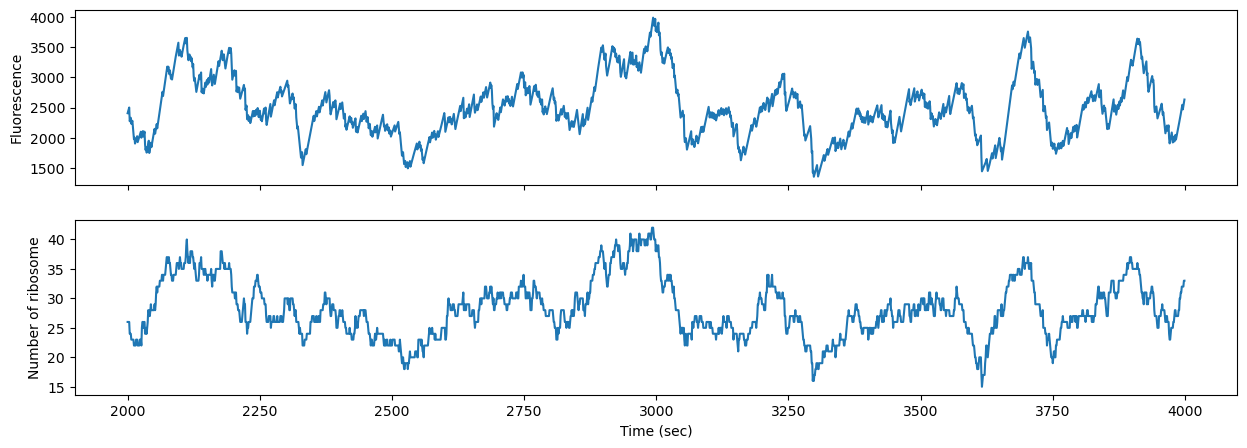

In [87]:
fig, axes = plt.subplots(nrows = 2, sharex=True)
min_ = 2000
max_ = 4000  # nb point
step_ = 10
axes[0].plot(x_global1[::step_][min_:max_], y_global1[::step_][min_:max_])
axes[1].plot(x_global1[::step_][min_:max_], y_start1[::step_][min_:max_])

axes[0].set_ylabel("Fluorescence")
axes[1].set_ylabel("Number of ribosome")
axes[1].set_xlabel("Time (sec)")

fig.set_size_inches((15,5))

Text(0.5, 0, 'Time (sec)')

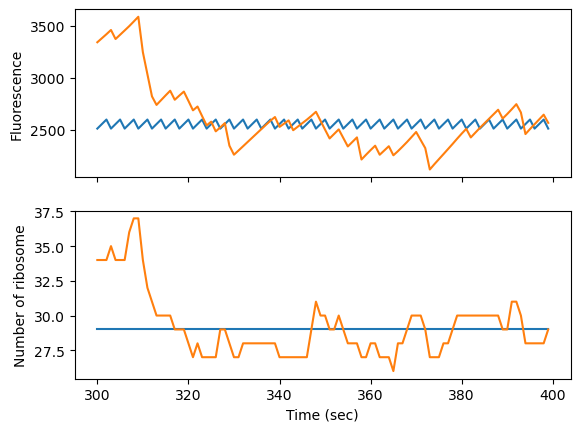

In [88]:
fig, axes = plt.subplots(nrows = 2, sharex=True)
min_ = 300
max_ = 400
step_ = 10  
axes[0].plot(x_global[::step_][min_:max_], y_global[::step_][min_:max_])
axes[1].plot(x_global[::step_][min_:max_], y_start[::step_][min_:max_])
axes[0].plot(x_global1[::step_][min_:max_], y_global1[::step_][min_:max_])
axes[1].plot(x_global1[::step_][min_:max_], y_start1[::step_][min_:max_])

axes[0].set_ylabel("Fluorescence")
axes[1].set_ylabel("Number of ribosome")
axes[1].set_xlabel("Time (sec)")

In [110]:
def autocorrelation_new(x, lags):
    '''manualy compute, non partial'''

    mean=np.mean(x)
    var=np.var(x)
    xp=x-mean
    corr=[1. if l==0 else np.sum(xp[l:]*xp[:-l])/len(x)/var for l in lags]

    return np.array(corr)/corr[1]


def autocorrelation_new2(intensity):
    """
    Compute the normalized intensity autocorrelation function using a for loop.
    G(τ) = <δI(t) δI(t+τ)> / <I(t)>^2
    """
    I = np.array(intensity, dtype=float)
    N = len(I)
    
    I_mean = np.mean(I)
    delta_I = I - I_mean
    
    G = np.zeros(N)
    
    for tau in range(N):
        # compute <δI(t) δI(t+τ)>
        products = delta_I[:N - tau] * delta_I[tau:]
        G[tau] = np.mean(products) / (I_mean ** 2)
    
    tau = np.arange(N)
    return tau, G

def autocorrelation_new3(intensity):
    """
    Compute the normalized intensity autocorrelation function:
        G(τ) = <δI(t) δI(t+τ)> / <I(t)>^2
    where δI(t) = I(t) - <I(t)>
    """
    I = np.array(intensity, dtype=float)
    N = len(I)

    # Mean intensity
    I_mean = np.mean(I)
    delta_I = I - I_mean

    # Compute autocorrelation via FFT (efficient method)
    # Pad to 2N for no circular overlap
    f = np.fft.fft(delta_I, n=2*N)
    ac = np.fft.ifft(f * np.conjugate(f))[:N].real

    # Normalize
    ac /= np.arange(N, 0, -1)   # correct for reduced pairs at long τ
    G = ac / (I_mean ** 2)

    # Lag times
    tau = np.arange(N)

    return tau, G

  
start_ = 3700
end_ = 3900
step_ = 10
x_auto, y_auto = autocorrelation(y_global1[::step_][start_:end_], 1, )
y_auto1 = autocorrelation_new(y_global1[::step_][start_:end_], range(end_-start_))
pair2, y_auto2 = autocorrelation_new2(y_global1[::step_][start_:end_])
tau, y_auto3 = autocorrelation_new3(y_global1[::step_][start_:end_])
# corr

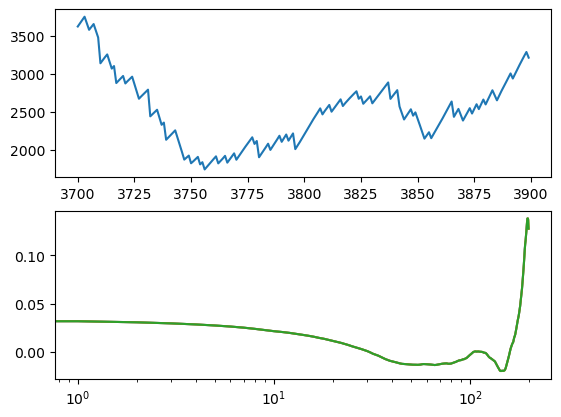

In [111]:
fig, axes= plt.subplots(nrows=2)

i = 1
# axes[0].plot(datas[datas["TRACK_ID"]==i]["FRAME"][::10][:200].to_numpy(), 
#              datas[datas["TRACK_ID"]==i]["MEAN_INTENSITY_CH1"][::10][:200].to_numpy())

axes[0].plot(x_global1[::step_][start_:end_], 
             y_global1[::step_][start_:end_])

x_auto, y_auto = autocorrelation(y_global1[::step_][start_:end_], 
                             1, 
                                 )
axes[1].plot(x_auto, y_auto)
# axes[1].plot(np.arange(0, len(y_auto1)), y_auto1)
axes[1].plot(pair2, y_auto2)
axes[1].plot(np.arange(0, len(y_auto3)), y_auto3)
axes[1].set_xscale("log")

In [112]:
import lmfit 

def fit_function_exact_part0(x, k, c, N):
    return (k/c)*(2/3)*(1/((N*(N+1))**2)) * np.exp(-k*x)


def fit_function_exact_part1(x, k, c, N, n):
    return (N-n)*(N-n+1)*(2*N+n+1)*((k*x)**n)/factorial(n)


def min_function(params, x, data):
    N = int(params["N"].value)
    model = np.float64(fit_function_exact_part1(x, params['k'], params['c'], N, 0))
    for n in range(1, N+1):
        model += np.float64(fit_function_exact_part1(x, params['k'], params['c'], N, n))

    model *= np.float64(fit_function_exact_part0(x, params['k'], params['c'], N))
    
    return model-data




###########################
params =lmfit.Parameters()
params.add("N", value = 32, vary = False)

params.add('k', value=24, min=0)
params.add('c', value=1, min=0)

# for i in range(params['N'].value):   # Adds the relaxation times and moduli separately
res = lmfit.minimize(min_function, params, args=(np.arange(0,len(y_auto)), y_auto))
res

In [113]:
def fit_function_exact(x, k, c, N):
    return (k/c)*(2/3)*(1/((N*(N+1))**2)) * np.exp(-k*x) * (
        sum((N-n)*(N-n+1)*(2*N+n+1)*(((k*x)**n)/factorial(n)) for n in range (0, int(N)))
    )

model = lmfit.Model(fit_function_exact)
params = lmfit.Parameters() 
params.add('N', value=32, vary=False)
params.add('k', value=1, min=0)
params.add('c', value=1, min=0)

result = model.fit(y_auto3, params, x=np.arange(0,len(y_auto3)))

result

curve
46.51002792228473 434.51890365982354
linear
47
27.574468085106382 656.889276633448


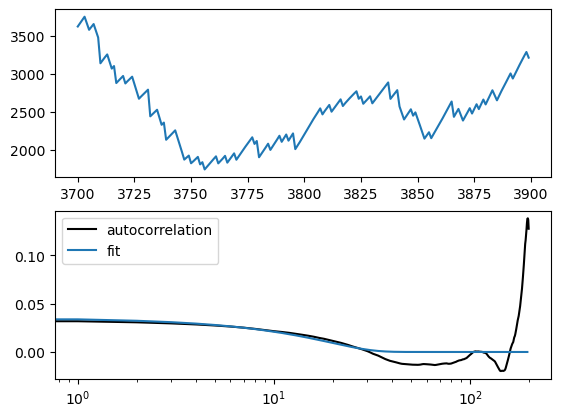

In [131]:
_,_, elongation_r, translation_init_r, perr=single_track_analysis(x_auto, y_auto3, 1, suntag_length+prot_length, method="curve")
print(elongation_r, translation_init_r)
_,_, elongation_r, translation_init_r, perr=single_track_analysis(x_auto, y_auto3, 1, suntag_length+prot_length, method="linear")
print(elongation_r, translation_init_r)


fig, axes = plt.subplots(nrows = 2)

axes[0].plot(x_global1[::step_][start_:end_], 
             y_global1[::step_][start_:end_])

axes[1].plot(np.arange(0,len(y_auto3)), y_auto3, c="black", label="autocorrelation")
# ax.plot(x_auto, y_auto + result.residual, c='r', ls='--', label="residuals")
axes[1].plot(x_auto, fit_function_exact(x_auto, result.params["k"].value, result.params["c"].value, result.params["N"].value), label = "fit")
axes[1].set_xscale("log")
# ax.set_yscale("log")
axes[1].legend()

In [115]:
import numpy as np
from scipy.optimize import curve_fit
from scipy.special import gammaln
import matplotlib.pyplot as plt

def model_G_tau(tau, k, c, N):
    """
    Model:
    G(τ) = (k/c)*(2/3)*1/(N(N+1))^2 * exp(-kτ) *
           Σ_{n=0}^{N} (N-n)(N-n+1)(2N+n+1)*(kτ)^n / n!
    """
    tau = np.asarray(tau, dtype=float)
    N = int(N)

    # prefactor
    denom = (N * (N + 1))**2 if N > 0 else 1.0
    prefactor = (k / c) * (2/3) / denom

    # precompute coefficients
    n = np.arange(0, N + 1)
    coef = (N - n) * (N - n + 1) * (2*N + n + 1)

    # factorial in log form for numerical stability
    ln_fact = gammaln(n + 1)

    # compute (kτ)^n / n! for all τ efficiently
    ktau = np.outer(k * tau, np.ones_like(n))
    with np.errstate(divide='ignore', invalid='ignore'):
        ln_term = n * np.log(ktau) - ln_fact
    term = np.exp(ln_term)
    term[np.isnan(term)] = 0.0  # handle 0^0 cases

    # sum over n
    summation = np.sum(coef * term, axis=1)

    return prefactor * np.exp(-k * tau) * summation


def fit_G_tau_known_N(tau, G_data, N, G_err=None, k0=1.0, c0=1.0, plot=True):
    """
    Fit G(τ) data for known integer N.
    """
    def model_fixed_N(tau, k, c):
        return model_G_tau(tau, k, c, N)

    popt, pcov = curve_fit(model_fixed_N, tau, G_data, p0=(k0, c0), sigma=G_err, absolute_sigma=True if G_err is not None else False)

    k_fit, c_fit = popt
    k_err, c_err = np.sqrt(np.diag(pcov))

    # if plot:
    #     plt.figure(figsize=(7,5))
    #     plt.plot(tau, G_data, 'o', label='Data', markersize=5)
    #     tau_fit = np.linspace(min(tau), max(tau), 300)
    #     plt.plot(tau_fit, model_G_tau(tau_fit, k_fit, c_fit, N), '-', label=f'Fit (N={N}, k={k_fit:.3g}, c={c_fit:.3g})')
    #     plt.xlabel("τ")
    #     plt.ylabel("G(τ)")
    #     plt.legend()
    #     plt.tight_layout()
    #     plt.show()

    return {"k": k_fit, "k_err": k_err, "c": c_fit, "c_err": c_err}

result_fit  = fit_G_tau_known_N(np.linspace(0, len(y_auto3), len(y_auto3)), y_auto3, N=32, k0=1.0, c0=1.0)
print(result_fit)

{'k': 0.9089648923461495, 'k_err': 0.4750801522362087, 'c': 1.0455199947381408, 'c_err': 0.44119413764205573}


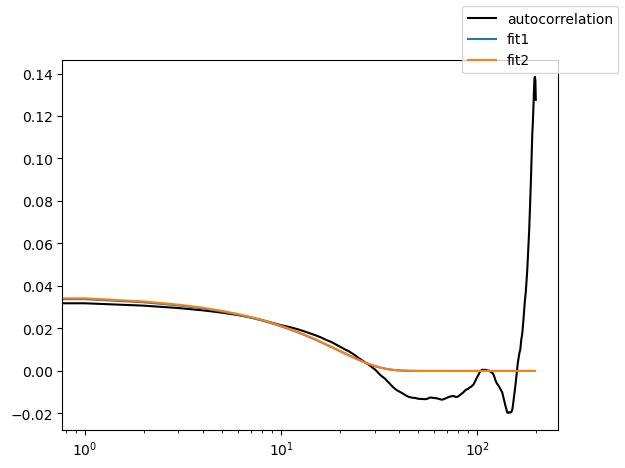

In [116]:
fig, ax = plt.subplots()
ax.plot(np.arange(0,len(y_auto3)), y_auto3, c="black", label="autocorrelation")
# ax.plot(x_auto, y_auto + result.residual, c='r', ls='--', label="residuals")
ax.plot(x_auto, fit_function_exact(x_auto, result.params["k"].value, result.params["c"].value, result.params["N"].value), label = "fit1")
ax.plot(x_auto, model_G_tau(x_auto, result_fit["k"], result_fit["c"], 32), label="fit2")
ax.set_xscale("log")
# ax.set_yscale("log")
fig.legend()

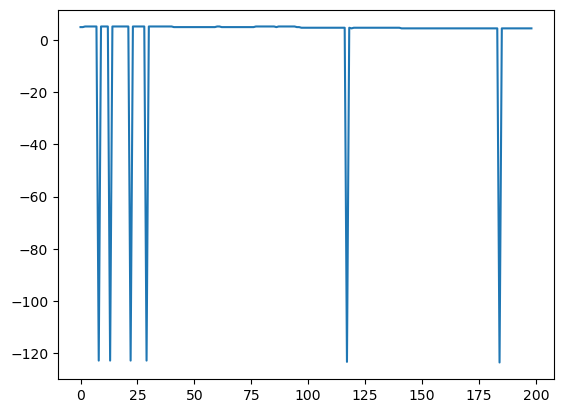

In [119]:
fig, ax = plt.subplots()
ax.plot(np.diff(y_global1[start_:end_]))

In [124]:
np.unique(np.diff(y_global), return_counts=True)

(array([-123.73869347,    0.24120603,    0.24120603,    0.24120603,
           0.24120603,    0.24120603,    0.24120603,    0.48241206,
           0.48241206,    0.48241206,    0.72361809,    0.72361809,
           0.72361809,    0.72361809,    0.72361809,    0.96482412,
           0.96482412,    0.96482412,    0.96482412,    1.20603015,
           1.20603015,    1.20603015,    1.20603015,    1.20603015,
           1.44723618,    1.44723618,    1.44723618,    1.44723618,
           1.44723618,    1.44723618,    1.68844221,    1.68844221,
           1.68844221,    1.68844221,    1.92964824,    1.92964824,
           1.92964824,    1.92964824,    2.17085427,    2.17085427,
           2.17085427,    2.4120603 ,    2.4120603 ,    2.4120603 ,
           2.4120603 ,    2.65326633,    2.65326633,    2.65326633,
           2.65326633,    2.89447236,    2.89447236,    2.89447236,
           2.89447236,    2.89447236,    2.89447236,    2.89447236,
           2.89447236,    3.13567839,    3.13567